In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os

plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RESULTS_DIR = "results"

df = pd.read_csv(os.path.join(RESULTS_DIR, "summary.csv"))
print(f"Loaded {len(df)} scenarios")
df.head()

Loaded 351 scenarios


,id,n_nodes,n_entries,n_exits,spawn_prob,bad_driver_frac,v_max,avg_velocity,avg_density,avg_flow,avg_queue,max_queue,pct_congested,first_cong_step,npz,pkl
0,0,4,1,1,0.01,0.0,30.0,26.9019,0.011560,0.3403,3.5733,7,0.53,248,results/ring4_e1x1_sp0.01_bd0.0_vm30.npz,results/ring4_e1x1_sp0.01_bd0.0_vm30.pkl
1,1,4,1,1,0.01,0.0,50.0,45.7095,0.006050,0.2956,0.4207,4,0.67,184,results/ring4_e1x1_sp0.01_bd0.0_vm50.npz,results/ring4_e1x1_sp0.01_bd0.0_vm50.pkl
2,2,4,1,1,0.01,0.0,70.0,62.7496,0.008634,0.5725,0.7960,4,1.07,164,results/ring4_e1x1_sp0.01_bd0.0_vm70.npz,results/ring4_e1x1_sp0.01_bd0.0_vm70.pkl
3,3,4,1,1,0.01,0.1,30.0,27.4190,0.007336,0.2168,2.6707,6,0.70,210,results/ring4_e1x1_sp0.01_bd0.1_vm30.npz,results/ring4_e1x1_sp0.01_bd0.1_vm30.pkl
4,4,4,1,1,0.01,0.1,50.0,44.9280,0.008656,0.4173,1.0733,6,0.63,210,results/ring4_e1x1_sp0.01_bd0.1_vm50.npz,results/ring4_e1x1_sp0.01_bd0.1_vm50.pkl


## 1 — Congestion rate by topology

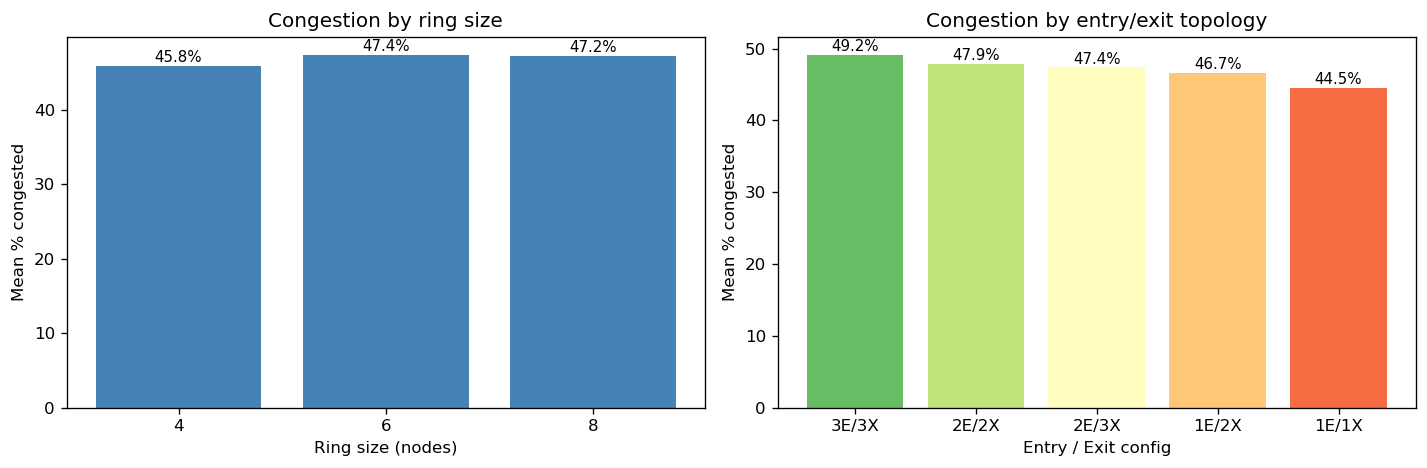

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- left: congestion % by ring size ---
ax = axes[0]
grouped = df.groupby("n_nodes")["pct_congested"].mean()
ax.bar(grouped.index.astype(str), grouped.values, color="steelblue")
ax.set_xlabel("Ring size (nodes)")
ax.set_ylabel("Mean % congested")
ax.set_title("Congestion by ring size")
for i, v in enumerate(grouped.values):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

# --- right: congestion % by (n_entries, n_exits) ---
ax = axes[1]
df["topology"] = df.apply(lambda r: f"{int(r.n_entries)}E/{int(r.n_exits)}X", axis=1)
grouped2 = df.groupby("topology")["pct_congested"].mean().sort_values(ascending=False)
colors = cm.RdYlGn_r(np.linspace(0.2, 0.8, len(grouped2)))
bars = ax.bar(grouped2.index, grouped2.values, color=colors)
ax.set_xlabel("Entry / Exit config")
ax.set_ylabel("Mean % congested")
ax.set_title("Congestion by entry/exit topology")
for bar, v in zip(bars, grouped2.values):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

## 2 — Effect of each parameter (sweep plots)

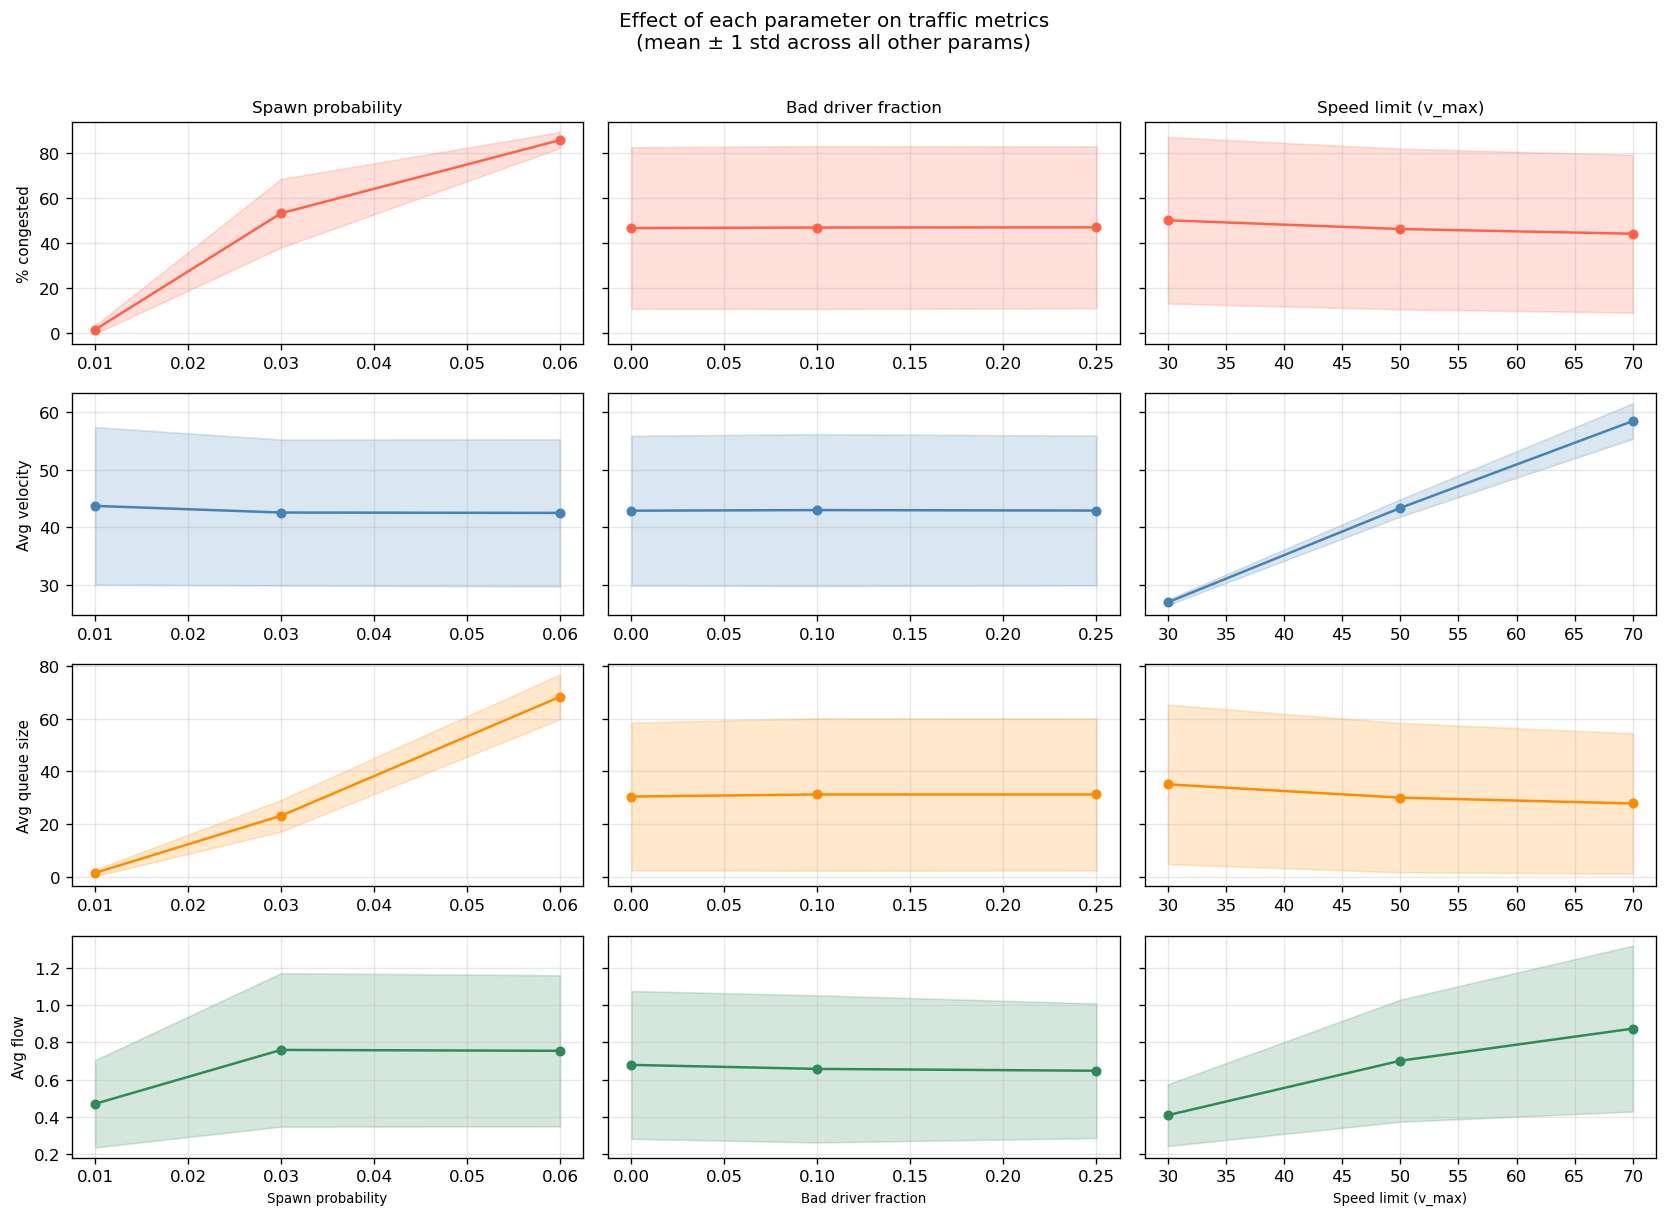

In [26]:
params = [
    ("spawn_prob",      "Spawn probability"),
    ("bad_driver_frac", "Bad driver fraction"),
    ("v_max",           "Speed limit (v_max)"),
]
metrics_to_plot = [
    ("pct_congested", "% congested",    "tomato"),
    ("avg_velocity",  "Avg velocity",   "steelblue"),
    ("avg_queue",     "Avg queue size", "darkorange"),
    ("avg_flow",      "Avg flow",       "seagreen"),
]

fig, axes = plt.subplots(len(metrics_to_plot), len(params), figsize=(14, 10), sharey="row")

for col, (param, param_label) in enumerate(params):
    for row, (metric, metric_label, color) in enumerate(metrics_to_plot):
        ax = axes[row][col]
        grouped = df.groupby(param)[metric].agg(["mean", "std"])
        xs = grouped.index.values
        ax.plot(xs, grouped["mean"].values, "o-", color=color, lw=1.5, ms=5)
        ax.fill_between(xs,
                        grouped["mean"] - grouped["std"],
                        grouped["mean"] + grouped["std"],
                        alpha=0.2, color=color)
        if row == 0:
            ax.set_title(param_label, fontsize=10)
        if col == 0:
            ax.set_ylabel(metric_label, fontsize=9)
        ax.set_xlabel(param_label if row == len(metrics_to_plot) - 1 else "", fontsize=8)
        ax.grid(True, alpha=0.3)

plt.suptitle("Effect of each parameter on traffic metrics\n(mean ± 1 std across all other params)", y=1.01)
plt.tight_layout()
plt.show()

## 3 — Heatmaps: pairwise parameter interactions

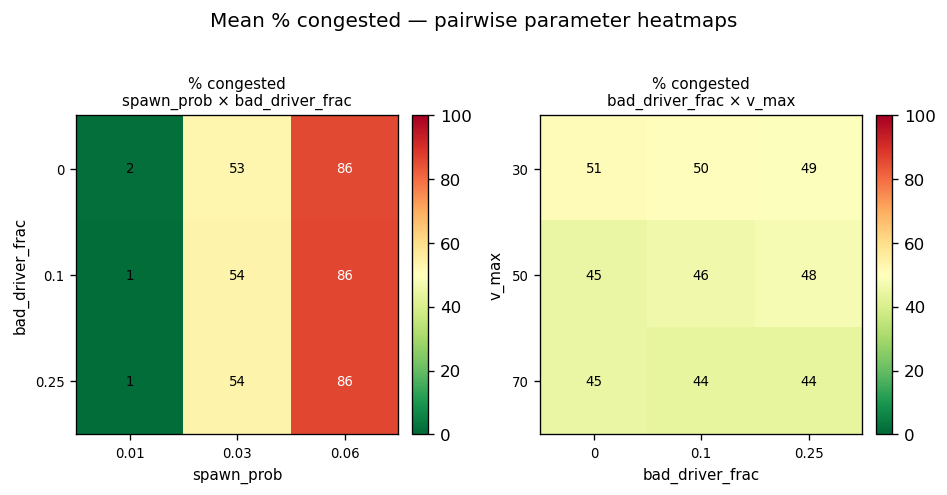

In [27]:
pairs = [
    ("spawn_prob",      "bad_driver_frac"),
    ("bad_driver_frac", "v_max"),
]

fig, axes = plt.subplots(1, len(pairs), figsize=(8, 4))

for ax, (xp, yp) in zip(axes, pairs):
    pivot = df.pivot_table(values="pct_congested", index=yp, columns=xp, aggfunc="mean")
    im = ax.imshow(pivot.values, aspect="auto", cmap="RdYlGn_r", vmin=0, vmax=100)
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_xticklabels([f"{v:.2g}" for v in pivot.columns], fontsize=8)
    ax.set_yticklabels([f"{v:.2g}" for v in pivot.index],   fontsize=8)
    ax.set_xlabel(xp, fontsize=9)
    ax.set_ylabel(yp, fontsize=9)
    ax.set_title(f"% congested\n{xp} × {yp}", fontsize=9)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=8,
                        color="white" if val > 60 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle("Mean % congested — pairwise parameter heatmaps", y=1.02)
plt.tight_layout()
plt.show()

## 4 — Time-series deep-dive: best vs worst scenarios

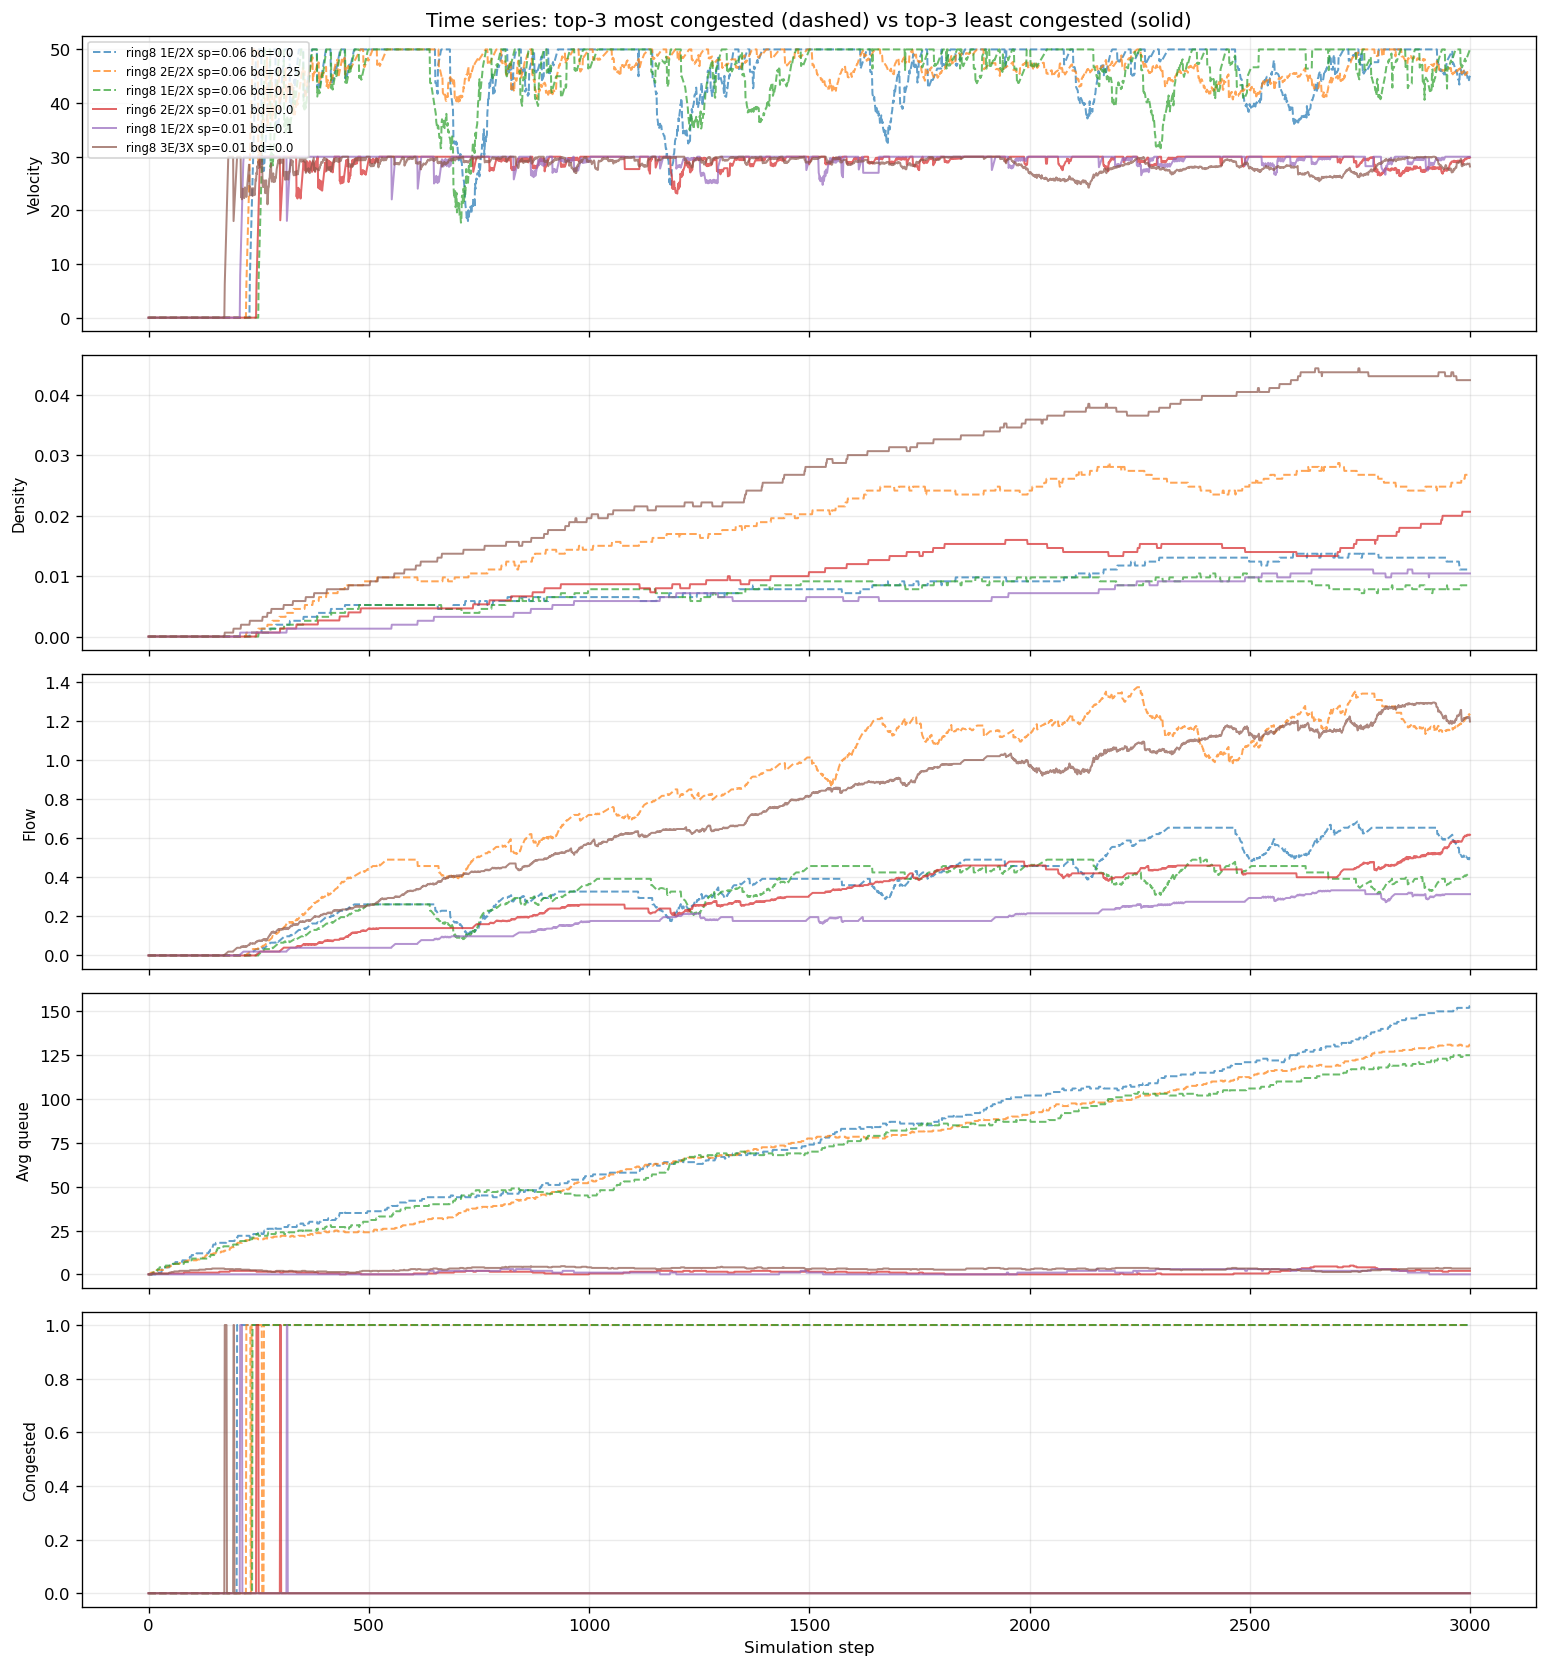

In [29]:
def load_npz(row):
    return np.load(row["npz"])["traffic"]

# Pick 3 least and 3 most congested scenarios
top3    = df.nlargest(3,  "pct_congested")
bottom3 = df.nsmallest(3, "pct_congested")
selected = pd.concat([top3, bottom3])

ts_metrics = [
    ("velocity",  "Velocity",    "steelblue"),
    ("density",   "Density",     "darkorange"),
    ("flow",      "Flow",        "seagreen"),
    ("queue",     "Avg queue",   "purple"),
    ("congested", "Congested",   "tomato"),
]

fig, axes = plt.subplots(len(ts_metrics), 1, figsize=(13, 14), sharex=True)

for row_idx, (_, row) in enumerate(selected.iterrows()):
    data = load_npz(row)
    label = (f"ring{int(row.n_nodes)} {int(row.n_entries)}E/{int(row.n_exits)}X "
             f"sp={row.spawn_prob} bd={row.bad_driver_frac} ")
    style = "--" if row_idx < 3 else "-"
    alpha = 0.7

    for ax, (field, _, color) in zip(axes, ts_metrics):
        ax.plot(data[field].astype(float), linestyle=style, alpha=alpha, lw=1.2,
                label=label if field == "velocity" else "")

for ax, (field, ylabel, color) in zip(axes, ts_metrics):
    ax.set_ylabel(ylabel, fontsize=9)
    ax.grid(True, alpha=0.25)

axes[0].set_title("Time series: top-3 most congested (dashed) vs top-3 least congested (solid)")
axes[0].legend(fontsize=7, loc="upper left", ncol=1)
axes[-1].set_xlabel("Simulation step")
plt.tight_layout()
plt.show()

## 5 — Fundamental diagram (flow vs density)

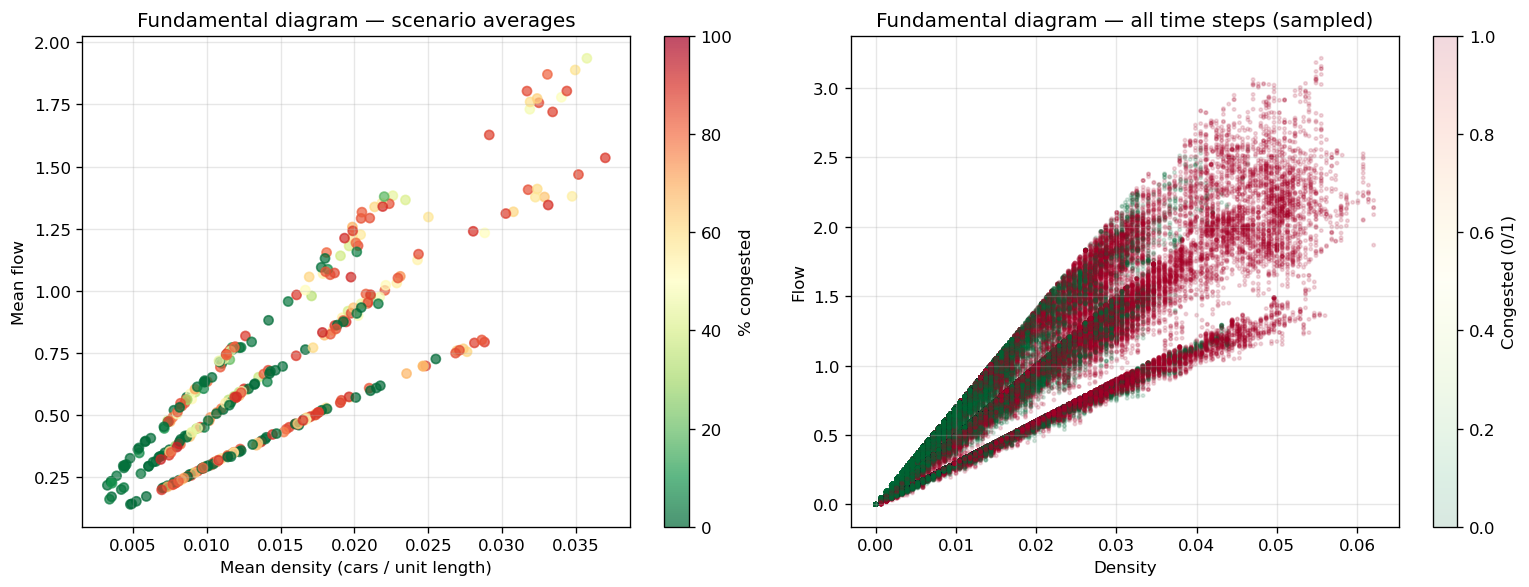

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- scatter: one point per scenario ---
ax = axes[0]
sc = ax.scatter(df["avg_density"], df["avg_flow"],
                c=df["pct_congested"], cmap="RdYlGn_r",
                vmin=0, vmax=100, alpha=0.7, s=30)
plt.colorbar(sc, ax=ax, label="% congested")
ax.set_xlabel("Mean density (cars / unit length)")
ax.set_ylabel("Mean flow")
ax.set_title("Fundamental diagram — scenario averages")
ax.grid(True, alpha=0.3)

# --- time-series scatter: sample every 10 steps from all scenarios ---
ax = axes[1]
sample_density, sample_flow, sample_cong = [], [], []
for _, row in df.iterrows():
    try:
        ts = np.load(row["npz"])["traffic"]
        sample_density.extend(ts["density"][::10].tolist())
        sample_flow.extend(   ts["flow"][::10].tolist())
        sample_cong.extend(   ts["congested"][::10].astype(float).tolist())
    except Exception:
        pass

sc2 = ax.scatter(sample_density, sample_flow, c=sample_cong,
                 cmap="RdYlGn_r", alpha=0.15, s=4, vmin=0, vmax=1)
plt.colorbar(sc2, ax=ax, label="Congested (0/1)")
ax.set_xlabel("Density")
ax.set_ylabel("Flow")
ax.set_title("Fundamental diagram — all time steps (sampled)")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6 — First congestion step distribution

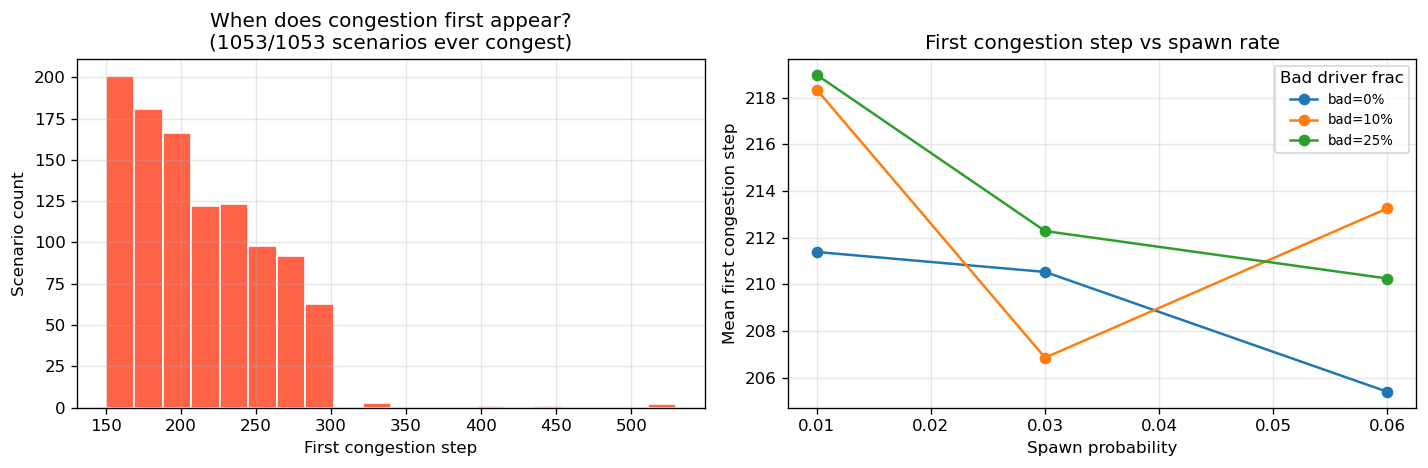

In [ ]:
ever_congested = df[df["first_cong_step"] >= 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- histogram of first congestion step ---
ax = axes[0]
ax.hist(ever_congested["first_cong_step"], bins=20, color="tomato", edgecolor="white")
ax.set_xlabel("First congestion step")
ax.set_ylabel("Scenario count")
ax.set_title(f"When does congestion first appear?\n({len(ever_congested)}/{len(df)} scenarios ever congest)")
ax.grid(True, alpha=0.3)

# --- first congestion step vs spawn_prob, coloured by bad_driver_frac ---
ax = axes[1]
for bd in sorted(ever_congested["bad_driver_frac"].unique()):
    sub = ever_congested[ever_congested["bad_driver_frac"] == bd]
    grouped = sub.groupby("spawn_prob")["first_cong_step"].mean()
    ax.plot(grouped.index, grouped.values, "o-", ms=6, label=f"bad={bd:.0%}")
ax.set_xlabel("Spawn probability")
ax.set_ylabel("Mean first congestion step")
ax.set_title("First congestion step vs spawn rate")
ax.legend(title="Bad driver frac", fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()